:# Session 3 - Microscale

*By Robin Furze and Joshua Montgomery*

In this session an example microcale for tribology is presented. This microscale model is essential for use within in the HMM. The code presented in this session will feature heavily in the HMM model

---
### Downloading the Necessary Packages

Many different solvers can be used. In this workshope, NGSOLVE is used. This is because it solves quickly and can be installed into a Google Colab environment. When the following code snippet may take a while to run initally, NGSOLVE will only need to be installed once.

In [3]:
try:
    import ngsolve
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/ngsolve-install-release-real.sh" -O "/tmp/ngsolve-install.sh" && bash "/tmp/ngsolve-install.sh"
    import ngsolve

from ngsolve import *
from ngsolve.webgui import Draw
from ngsolve.meshes import *
from netgen.meshing import *
import matplotlib.pyplot as plt

from ngsolve.solvers import *
import numpy as np
from ngsolve.webgui import Draw

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

---
### Inputs

Various parameters are arbitrarily defined for this example. Feel free to tweak these parameters.

In [14]:
## Physical Parameters
U = 2 #Fluid velocity (m/s)
eta = 0.1 # Fluid viscosity (Pa.s)
rho = 1 # Fluid density (kgm^-3)
h0 = 0.1 # Inital film thickness (m)
Ah = 10e-3 # Microscale roughness (m)
p0=100 # Initial Microscale Pressure (Pa)
dpdx0=1 # Initial pressure gradient (Pa/m)

## Meshing
k = 1 # Order of elements
Ne_m = 75 # Microscale Number of elements
lm = 5e-3 # Microscale length (m)

## Convergence Paramaters
Newton_tol = 1e-6 # Newton solver tolerance (macro and micro)


---
### Microscale Setup
**build_micro_mesh** - This function builds the microscale mesh. Complexity is introduced through the need to implement periodicity. That is to say that the film thickness must be the same at both boundaries. This is simple to implement in one dimension.

**Solve_microscale** - Builds and executes the microscale models across the mesh created in the previous function.


In [31]:
#Creates the microscale mesh
def build_micro_mesh(n, Lx):
  mesh = Mesh(dim=1)
  pids = []
  for i in range(n+1):
      pids.append (mesh.Add (MeshPoint(Pnt(i/n, 0, 0))))
  for i in range(n):
      mesh.Add(Element1D([pids[i],pids[i+1]],index=1))
  mesh.Add (Element0D( pids[0], index=1))
  mesh.Add (Element0D( pids[n], index=2))
  mesh.AddPointIdentification(pids[0],pids[n],1,2)
  mesh.SetBCName(0, "left")
  mesh.SetBCName(1, "right")
  meshout = ngsolve.Mesh(mesh)
  boundaries = meshout.GetBoundaries()
  return meshout


def Solve_microscale(zeta_i, meshm, ref, lx):
  # Unpack zeta
  h0, p0, dpdx0 = zeta_i
  k = 1 # Order of microscale elements

  # Pressure gain/drop
  dpx = dpdx0 * lx # pressure increase from left to right
  # Reference pressure for point constraint - avoiding negative pressures
  pr = p0 - 0.5*dpx
  pm = pr + (dpx if dpx < 0 else 0.0)
  pconst = pr if pm >= 0.0 else (pr - pm)

  # Film thickness function
  def hg(x, h0):
    return h0 + Ah * cos(2 * pi * x*lx / lx)

  # Create a H1, order k space for the pressure field
  V_micro = Compress(H1(meshm, order=k)) # All boundaries are set to dirichlet, p = 0
  V_micro.FreeDofs()[0] = False #Set the first boundary DOF as fixed - we set this to a reference value later
  V_micro.FreeDofs()[-1] = False #Set the last boundary DOF as fixed

  p = V_micro.TrialFunction()  # Pressure trial function
  v = V_micro.TestFunction()   # Pressure test function
  sol = GridFunction(V_micro)  # solution
  sol.vec[0] = pconst # Fix corner pressure value
  sol.vec[-1] = pconst + dpx

  a_micro = BilinearForm(V_micro)
  h = hg(x, h0)
  a_micro += (h**3 /  (12 * eta * lx)) * grad(p) * grad(v) * dx - (U/2) * h * grad(v) * dx
  a_micro.Assemble()

  # Solve the model
  Newton(
      a_micro,
      sol,
      freedofs=V_micro.FreeDofs(),
      maxit=200,
      maxerr=Newton_tol,
      inverse="umfpack",
      printing=False,
  )
  p_micro = GridFunction(V_micro)
  film_micro = GridFunction(V_micro)
  dpdx_micro = GridFunction(V_micro)
  p_micro.Set(sol)
  film_micro.Set(h)
  dpdx_calc = grad(p_micro)/lm
  dpdx_micro.Set(dpdx_calc)

  qx = U * h / 2 - h**3 * dpdx_micro / (12 * eta)

  # Homogenise the variables
  Pst = Integrate(p_micro, meshm)
  Qst = Integrate(qx, meshm)

  #Find the maximum and mininmum values
  pmax = np.max(p_micro.vec.data)
  pmin = np.min(p_micro.vec.data)
  hmax = np.max(film_micro.vec.data)
  hmin = np.min(film_micro.vec.data)
  p=p_micro.vec.data
  h=film_micro.vec.data
  return Pst, Qst, pmax, pmin, hmax, hmin, p, h



---
### Run Microscale
The microscale is ran with arbitrary inputs.


In [33]:
zeta_i= h0, p0, dpdx0
mesh_m = build_micro_mesh(Ne_m, lm)
Pst, Qst, pmax, pmin, hmax, hmin, p_micro,h = Solve_microscale(zeta_i, mesh_m, 1, lx = lm)


---
### Plotting

Plot of microscale outputs.

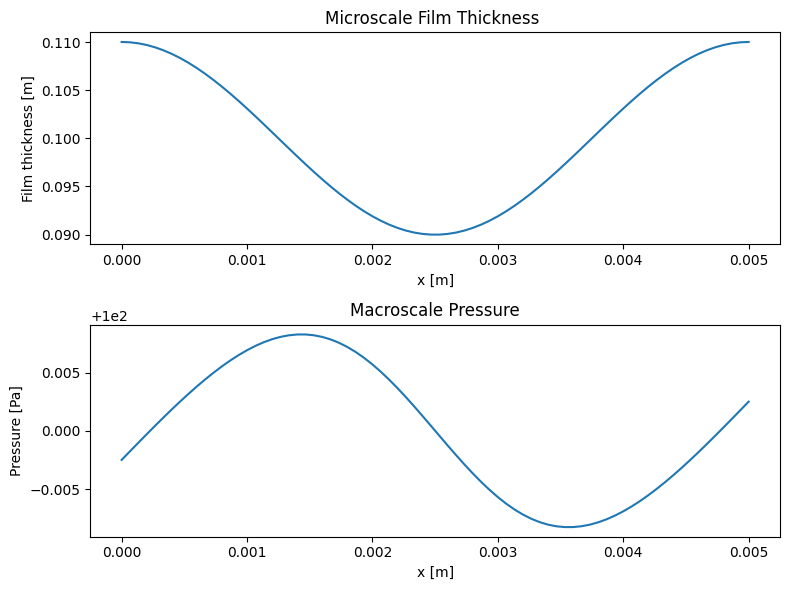

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))


x_vals = np.linspace(0, lm, np.size(p_micro))


axes[0].plot(x_vals, h)
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("Film thickness [m]")
axes[0].set_title("Microscale Film Thickness ")

axes[1].plot(x_vals, p_micro)
axes[1].set_xlabel("x [m]")
axes[1].set_ylabel("Pressure [Pa]")
axes[1].set_title("Macroscale Pressure")

plt.tight_layout()
plt.show()